# BaristaBot : Un système de commande conversationnel avec LangGraph et Gemini

Ce notebook vous guide à travers la création de **BaristaBot**, un agent intelligent capable de prendre des commandes de café en langage naturel, de gérer un menu dynamique et de confirmer des commandes complexes via un graphe d'état.

### 1. Installation des dépendances
Nous commençons par installer les bibliothèques nécessaires : `langgraph` pour l'orchestration, `langchain-google-genai` pour l'intégration Gemini, et le SDK `google-genai`.

In [1]:
%pip install -qU langgraph langchain-google-genai google-genai

### 2. Configuration de la clé API
Nous utilisons les secrets de Colab (ou l'environnement) pour configurer `GOOGLE_API_KEY`. Note : Pour Colab, utilisez `userdata.get`, mais ici nous suivons l'instruction pour un environnement type Kaggle/Standard.

In [2]:
import os
try:
    # Tentative de récupération de la clé API depuis les secrets Colab
    from google.colab import userdata
    GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
except:
    # Valeur par défaut si exécuté hors Colab (à remplacer par votre clé)
    GOOGLE_API_KEY = "VOTRE_CLE_ICI"

# Configuration de la variable d'environnement pour que les outils LangChain l'utilisent
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

### 3. Définition de l'état (State) et des instructions
L'état `OrderState` permet de suivre l'historique des messages, le contenu de la commande et si la session est terminée. `add_messages` permet d'accumuler les messages au lieu de les écraser.

In [40]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

# Définition de la structure de l'état du graphe
class OrderState(TypedDict):
    # add_messages permet d'ajouter les nouveaux messages à la liste existante au lieu de la remplacer
    messages: Annotated[list, add_messages]
    # Liste simple pour stocker les articles commandés
    order: list[str]
    # Indicateur booléen pour savoir si la conversation est terminée
    finished: bool

# Instructions système pour définir le comportement du chatbot
BARISTABOT_SYSINT = (
    "system",
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items. "
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "Always confirm_order with the user before calling place_order. "
)

WELCOME_MSG = "Bienvenue au café BaristaBot. Tapez `q` pour quitter. Comment puis-je vous servir aujourd'hui ?"

### 4. Définir un chatbot à tour unique
Nous créons un premier graphe simple pour tester la réponse du LLM.

In [41]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialisation du modèle Gemini 1.5 Flash (stable)
# On passe explicitement la clé API pour éviter les erreurs d'authentification
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash", google_api_key=GOOGLE_API_KEY)

# Nœud Chatbot : il prend l'état actuel, prépare l'historique et invoque le LLM
def chatbot(state: OrderState) -> OrderState:
    # On concatène les instructions système avec l'historique des messages
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    # On retourne le message généré par l'IA pour qu'il soit ajouté à l'état
    return {"messages": [llm.invoke(message_history)]}

# Construction du graphe de base
graph_builder = StateGraph(OrderState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Compilation du graphe en application exécutable
chat_graph = graph_builder.compile()

### 5. Visualisation du graphique

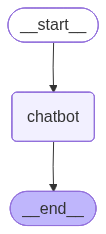

In [42]:
from IPython.display import Image, display
try:
    display(Image(chat_graph.get_graph().draw_mermaid_png()))
except:
    print("La visualisation nécessite pypydot et mermaid.")

### 6 & 7. Exécution et test manuel
On simule un tour de conversation.

In [43]:
try:
    initial_state = {"messages": [("user", "Bonjour !")], "order": [], "finished": False}
    state = chat_graph.invoke(initial_state)

    for msg in state["messages"]:
        print(f"{type(msg).__name__}: {msg.content}")
except Exception as e:
    print(f"Erreur confirmée : {e}")
    print("\nNote: Si l'erreur 404 persiste, cela peut être dû à une restriction régionale ou à une clé API qui n'a pas accès à ce modèle spécifique.")

HumanMessage: Bonjour !
AIMessage: Bonjour ! Welcome to BaristaBot, your friendly cafe ordering system. How can I help you today? Feel free to ask about our menu items, or let me know what you'd like to order!

We have a variety of:
*   **Coffee & Espresso**
*   **Tea**
*   **Pastries**
*   **Sandwiches**
*   **Smoothies**

What are you in the mood for?


### 8 & 9. Ajout d'un nœud humain et bouclage
Nous ajoutons une interaction réelle et une condition de sortie.

In [44]:
from langchain_core.messages.ai import AIMessage
from typing import Literal

# Nœud pour l'interaction humaine via la console
def human_node(state: OrderState) -> OrderState:
    last_msg = state["messages"][-1]
    print("BaristaBot:", last_msg.content)
    # Pause l'exécution pour attendre la saisie de l'utilisateur
    user_input = input("Vous: ")

    # Gestion de la sortie de la boucle par l'utilisateur
    if user_input.lower() in {"q", "quit", "exit"}:
        return {**state, "messages": [("user", user_input)], "finished": True}
    return {**state, "messages": [("user", user_input)]}

# Fonction de routage conditionnel pour sortir du graphe si fini
def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    if state.get("finished", False): return END
    return "chatbot"

# Création d'un graphe avec interaction cyclique entre bot et humain
builder = StateGraph(OrderState)
builder.add_node("chatbot", chatbot)
builder.add_node("human", human_node)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", "human")
builder.add_conditional_edges("human", maybe_exit_human_node)

chat_with_human_graph = builder.compile()

### 10. Menu dynamique avec Outils (Tools)
Définition de l'outil `get_menu` pour fournir la carte en temps réel.

In [45]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

@tool
def get_menu() -> str:
    """Fournit le menu à jour du café BaristaBot."""
    return """
    MENU:
    Cafés: Espresso, Americano, Cold Brew, Latte, Cappuccino
    Thés: English Breakfast, Thé Vert, Earl Grey
    Modificateurs: Lait d'avoine, Lait d'amande, Sirop de vanille, Sucre
    """

# Initialisation du ToolNode
tools = [get_menu]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

### 11 & 12. Gestion complète des commandes et Graphe Final
Implémentation du `order_node` pour gérer la logique métier (ajouter, confirmer, passer commande).

In [46]:
from langchain_core.messages.tool import ToolMessage
from random import randint
from typing import Literal

# Définition des outils (tools) que le LLM peut décider d'appeler
@tool
def add_to_order(drink: str, modifiers: list[str]) -> str: """Ajoute une boisson à la commande."""
@tool
def confirm_order() -> str: """Demande confirmation à l'utilisateur."""
@tool
def place_order() -> int: """Finalise la commande et retourne un numéro de commande."""

# Nœud de gestion de la logique de commande
def order_node(state: OrderState) -> OrderState:
    last_msg = state["messages"][-1]
    order = list(state.get("order", []))
    outbound_msgs = []
    finished = False

    # Itération sur les appels d'outils générés par le LLM
    for tool_call in last_msg.tool_calls:
        name = tool_call["name"]
        if name == "add_to_order":
            item = f"{tool_call['args']['drink']} ({', '.join(tool_call['args'].get('modifiers', []))})"
            order.append(item)
            res = f"Ajouté : {item}"
        elif name == "confirm_order":
            print(f"Commande actuelle: {order}")
            res = input("Est-ce correct ? ")
        elif name == "place_order":
            finished = True
            res = str(randint(1, 100)) # Génère un numéro de commande aléatoire

        # Création du message de retour d'outil obligatoire pour LangGraph
        outbound_msgs.append(ToolMessage(content=res, name=name, tool_call_id=tool_call["id"]))

    return {"messages": outbound_msgs, "order": order, "finished": finished}

# Logique de routage pour diriger vers les outils ou l'humain
def maybe_route_to_tools(state: OrderState) -> Literal["tools", "ordering", "human", "__end__"]:
    if state.get("finished", False): return END
    msg = state["messages"][-1]
    # Si le LLM a généré des tool_calls, on les exécute
    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        if any(tc["name"] == "get_menu" for tc in msg.tool_calls): return "tools"
        return "ordering"
    # Sinon, on rend la main à l'utilisateur
    return "human"

# Configuration finale : Liaison des outils au modèle LLM
llm_final = ChatGoogleGenerativeAI(model="gemini-1.5-flash", google_api_key=GOOGLE_API_KEY).bind_tools([get_menu, add_to_order, confirm_order, place_order])

def chatbot_v2(state: OrderState) -> OrderState:
    return {"messages": [llm_final.invoke([BARISTABOT_SYSINT] + state["messages"])]}

### 12. Assemblage final et Exécution

Nous configurons maintenant le graphe complet. Ce graphe permet au chatbot de décider s'il doit appeler un outil automatique (comme consulter le menu), gérer la commande (ajouter des articles), ou simplement répondre à l'utilisateur.

In [47]:
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END

# Reconstruction du graphe avec le modèle stable
builder = StateGraph(OrderState)
builder.add_node("chatbot", chatbot_v2)
builder.add_node("human", human_node)
builder.add_node("tools", ToolNode([get_menu]))
builder.add_node("ordering", order_node)

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", maybe_route_to_tools)
builder.add_conditional_edges("human", maybe_exit_human_node)
builder.add_edge("tools", "chatbot")
builder.add_edge("ordering", "chatbot")

barista_bot_app = builder.compile()

### Test Final

Vous pouvez maintenant lancer le bot. Essayez de commander un 'Latte avec du lait d'avoine' ou demandez quels sont les thés disponibles.

In [48]:
# Lancement de la boucle de conversation avec un état initial non vide
config = {"recursion_limit": 100}

try:
    # On commence avec un message de bienvenue pour éviter l'erreur 'contents are required'
    print(WELCOME_MSG)
    initial_input = {
        "messages": [("user", "Bonjour")],
        "order": [],
        "finished": False
    }

    final_state = barista_bot_app.invoke(initial_input, config)
    print("\n--- Session Terminée ---")
except Exception as e:
    print(f"Erreur: {e}")

Bienvenue au café BaristaBot. Tapez `q` pour quitter. Comment puis-je vous servir aujourd'hui ?
BaristaBot: Bonjour! Bienvenue chez BaristaBot. Que puis-je faire pour vous?
Vous: Je eux du thé
BaristaBot: Nous avons les thés suivants disponibles : English Breakfast, Thé Vert et Earl Grey. Lequel aimeriez-vous?
Vous: English breakfast
BaristaBot: Très bien, un thé English Breakfast. Autre chose?
Vous: non merci
Current Order: ['English Breakfast ()']
Is this correct? oui
BaristaBot: Votre commande est un thé English Breakfast. Est-ce exact?
Vous: oui

--- Session Terminée ---
